# 04. Comparación de modelos y regularizaciones — Dataset combinado v3

Este notebook compara cinco configuraciones representativas usando la misma división oficial del dataset v3:

- **A - Base**
- **B - Reducido**
- **C - L1 1e-5**
- **D - L2 1e-5**
- **E - Dropout 0.2**

El modelo B no aplica una penalización; reduce la complejidad de la arquitectura para comprobar si un modelo más pequeño mantiene un rendimiento competitivo.

## Cómo usar este notebook

- Selecciona el kernel **Python (Taller 3 - Train)**.
- `ACTIVAR_MODELO` decide qué modelos se incluyen.
- `REENTRENAR=False` reutiliza el checkpoint si existe.
- `REENTRENAR=True` vuelve a entrenar desde cero.
- Si un modelo está activo y no existe su checkpoint, se entrena automáticamente.
- Por defecto se reutilizan Base y L1, y se entrenan L2 y Dropout.
- Para comparar solo Base y L1, desactiva L2 y Dropout en `ACTIVAR_MODELO`.

In [1]:
import sys
import random
import datetime
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import Sequential, regularizers
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    TensorBoard,
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical

print("Python:", sys.version)
print("TensorFlow:", tf.__version__)
print("Ejecutable:", sys.executable)
print("CPU:", tf.config.list_physical_devices("CPU"))
print("GPU:", tf.config.list_physical_devices("GPU"))

Python: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
TensorFlow: 2.20.0
Ejecutable: c:\venvs\taller3-train\Scripts\python.exe
CPU: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
GPU: []


## 1. Rutas locales del proyecto

In [2]:
def encontrar_raiz_proyecto(inicio: Path) -> Path:
    inicio = inicio.resolve()

    for carpeta in [inicio, *inicio.parents]:
        if (carpeta / "regularizacion").exists():
            return carpeta

    raise FileNotFoundError(
        "No se encontró la carpeta 'regularizacion'. "
        "Abre la raíz completa del repositorio en VS Code."
    )


PROJECT_ROOT = encontrar_raiz_proyecto(Path.cwd())
REG_DIR = PROJECT_ROOT / "regularizacion"

DATA_DIR = REG_DIR / "data" / "v3"
X_PATH = DATA_DIR / "X_combined.npy"
Y_PATH = DATA_DIR / "Y_combined.npy"
SPLITS_PATH = DATA_DIR / "split_indices.npz"
METADATA_PATH = DATA_DIR / "metadata_combined.csv"

MODELS_DIR = REG_DIR / "models" / "v3"
CHECKPOINTS_DIR = MODELS_DIR / "checkpoints"
FINAL_DIR = MODELS_DIR / "final"

OUTPUTS_DIR = REG_DIR / "outputs" / "v3"
FIGURES_DIR = OUTPUTS_DIR / "figures"
METRICS_DIR = OUTPUTS_DIR / "metrics"
TENSORBOARD_DIR = OUTPUTS_DIR / "tensorboard"
HISTORIES_DIR = OUTPUTS_DIR / "histories"

for carpeta in [
    CHECKPOINTS_DIR,
    FINAL_DIR,
    FIGURES_DIR,
    METRICS_DIR,
    TENSORBOARD_DIR,
    HISTORIES_DIR,
]:
    carpeta.mkdir(parents=True, exist_ok=True)

for ruta in [X_PATH, Y_PATH, SPLITS_PATH, METADATA_PATH]:
    if not ruta.exists():
        raise FileNotFoundError(f"No se encontró el archivo requerido: {ruta}")

print("Raíz:", PROJECT_ROOT)
print("Dataset v3:", DATA_DIR)
print("Checkpoints:", CHECKPOINTS_DIR)
print("TensorBoard:", TENSORBOARD_DIR)

Raíz: C:\Users\Bastian\Desktop\Universidad\NOVENO SEMESTRE\IA\TALLER 3
Dataset v3: C:\Users\Bastian\Desktop\Universidad\NOVENO SEMESTRE\IA\TALLER 3\regularizacion\data\v3
Checkpoints: C:\Users\Bastian\Desktop\Universidad\NOVENO SEMESTRE\IA\TALLER 3\regularizacion\models\v3\checkpoints
TensorBoard: C:\Users\Bastian\Desktop\Universidad\NOVENO SEMESTRE\IA\TALLER 3\regularizacion\outputs\v3\tensorboard


## 2. Cargar el dataset v3 y la división oficial

In [3]:
X = np.load(X_PATH, mmap_mode="r")
y_enteras = np.load(Y_PATH).astype(np.int32)
metadata = pd.read_csv(METADATA_PATH)
splits = np.load(SPLITS_PATH)

indices_train = splits["train"]
indices_val = splits["validation"]
indices_test = splits["test"]

X_train = np.asarray(X[indices_train], dtype=np.float32)
X_val = np.asarray(X[indices_val], dtype=np.float32)

# El test se identifica, pero no se carga ni se evalúa en este notebook.
y_train_enteras = y_enteras[indices_train]
y_val_enteras = y_enteras[indices_val]

origen_train = metadata.iloc[indices_train]["Origen"].to_numpy()
origen_val = metadata.iloc[indices_val]["Origen"].to_numpy()

y_train = to_categorical(
    y_train_enteras,
    num_classes=10
).astype(np.float32)

y_val = to_categorical(
    y_val_enteras,
    num_classes=10
).astype(np.float32)

print("Entrenamiento:", X_train.shape, y_train.shape)
print("Validación:", X_val.shape, y_val.shape)
print("Prueba reservada:", len(indices_test), "imágenes")

print()
print(
    "Origen entrenamiento:",
    pd.Series(origen_train).value_counts().to_dict()
)
print(
    "Origen validación:",
    pd.Series(origen_val).value_counts().to_dict()
)

Entrenamiento: (5328, 64, 64, 1) (5328, 10)
Validación: (666, 64, 64, 1) (666, 10)
Prueba reservada: 666 imágenes

Origen entrenamiento: {'v2': 3677, 'v1': 1651}
Origen validación: {'v2': 461, 'v1': 205}


In [4]:
assert X_train.shape == (5328, 64, 64, 1)
assert X_val.shape == (666, 64, 64, 1)

assert y_train.shape == (5328, 10)
assert y_val.shape == (666, 10)

assert X_train.dtype == np.float32
assert X_val.dtype == np.float32
assert y_train.dtype == np.float32
assert y_val.dtype == np.float32

assert X_train.min() >= 0.0
assert X_train.max() <= 1.0
assert X_val.min() >= 0.0
assert X_val.max() <= 1.0

assert set(np.unique(origen_train)) == {"v1", "v2"}
assert set(np.unique(origen_val)) == {"v1", "v2"}

print("Comprobaciones del dataset v3 superadas.")

Comprobaciones del dataset v3 superadas.


## 3. Configuración común y modelos que se ejecutarán

In [ ]:
SEED = 42
BATCH_SIZE = 32
EPOCHS = 100
LEARNING_RATE = 0.001
PATIENCE = 10

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

# ACTIVAR_MODELO determina qué configuraciones participan.
# REENTRENAR determina si se ignora un checkpoint existente.
ACTIVAR_MODELO = {
    "A - Base": True,
    "B - Reducido": True,
    "C - L1 1e-5": True,
    "D - L2 1e-5": True,
    "E - Dropout 0.2": True,
}

REENTRENAR = {
    "A - Base": False,
    "B - Reducido": False,
    "C - L1 1e-5": False,
    "D - L2 1e-5": False,
    "E - Dropout 0.2": False,
}

print("Semilla:", SEED)
print("Batch size:", BATCH_SIZE)
print("Épocas máximas:", EPOCHS)
print("Modelos activos:", ACTIVAR_MODELO)
print("Reentrenar:", REENTRENAR)


Semilla: 42
Batch size: 32
Épocas máximas: 100
Modelos activos: {'A - Base': True, 'B - Reducido': True, 'C - L1 1e-5': True, 'D - L2 1e-5': True, 'E - Dropout 0.2': True}
Reentrenar: {'A - Base': False, 'B - Reducido': True, 'C - L1 1e-5': False, 'D - L2 1e-5': True, 'E - Dropout 0.2': True}


In [6]:
def crear_generador_entrenamiento(seed: int):
    generador = ImageDataGenerator(
        rotation_range=12,
        width_shift_range=0.08,
        height_shift_range=0.08,
        zoom_range=0.08,
        horizontal_flip=False,
        fill_mode="nearest",
    )

    return generador.flow(
        X_train,
        y_train,
        batch_size=BATCH_SIZE,
        shuffle=True,
        seed=seed,
    )


lote_x, lote_y = next(crear_generador_entrenamiento(SEED))

print("Lote de imágenes:", lote_x.shape)
print("Lote de etiquetas:", lote_y.shape)
print("Rango del lote:", float(lote_x.min()), "a", float(lote_x.max()))

Lote de imágenes: (32, 64, 64, 1)
Lote de etiquetas: (32, 10)
Rango del lote: 0.0 a 0.9903779029846191


## 4. Fábrica común de modelos

In [7]:
CONFIGURACIONES = {
    "A - Base": {
        "checkpoint": "modelo_A_base_mejor.keras",
        "filtros_1": 32,
        "filtros_2": 64,
        "unidades_densas": 64,
        "regularizador": None,
        "dropout": 0.0,
    },
    "B - Reducido": {
        "checkpoint": "modelo_B_reducido_mejor.keras",
        "filtros_1": 16,
        "filtros_2": 32,
        "unidades_densas": 32,
        "regularizador": None,
        "dropout": 0.0,
    },
    "C - L1 1e-5": {
        "checkpoint": "modelo_C_L1_1e5_mejor.keras",
        "filtros_1": 32,
        "filtros_2": 64,
        "unidades_densas": 64,
        "regularizador": regularizers.l1(1e-5),
        "dropout": 0.0,
    },
    "D - L2 1e-5": {
        "checkpoint": "modelo_D_L2_1e5_mejor.keras",
        "filtros_1": 32,
        "filtros_2": 64,
        "unidades_densas": 64,
        "regularizador": regularizers.l2(1e-5),
        "dropout": 0.0,
    },
    "E - Dropout 0.2": {
        "checkpoint": "modelo_E_Dropout_02_mejor.keras",
        "filtros_1": 32,
        "filtros_2": 64,
        "unidades_densas": 64,
        "regularizador": None,
        "dropout": 0.2,
    },
}


def crear_modelo(nombre: str, seed: int = SEED) -> tf.keras.Model:
    if nombre not in CONFIGURACIONES:
        raise ValueError(f"Configuración desconocida: {nombre}")

    tf.keras.backend.clear_session()
    random.seed(seed)
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)

    config = CONFIGURACIONES[nombre]

    capas = [
        Input(shape=(64, 64, 1), name="Entrada"),
        Conv2D(
            filters=config["filtros_1"],
            kernel_size=(3, 3),
            activation="relu",
            name="Convolucion_1",
        ),
        MaxPooling2D(
            pool_size=(2, 2),
            name="Pooling_1",
        ),
        Conv2D(
            filters=config["filtros_2"],
            kernel_size=(3, 3),
            activation="relu",
            name="Convolucion_2",
        ),
        MaxPooling2D(
            pool_size=(2, 2),
            name="Pooling_2",
        ),
        Flatten(name="Aplanado"),
        Dense(
            units=config["unidades_densas"],
            activation="relu",
            kernel_regularizer=config["regularizador"],
            name="Capa_Densa",
        ),
    ]

    if config["dropout"] > 0:
        capas.append(
            Dropout(
                rate=config["dropout"],
                name="Dropout_20",
            )
        )

    capas.append(
        Dense(
            units=10,
            activation="softmax",
            name="Salida",
        )
    )

    modelo = Sequential(
        capas,
        name=nombre.replace(" ", "_").replace("-", ""),
    )

    modelo.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )

    return modelo


for nombre in CONFIGURACIONES:
    modelo_temporal = crear_modelo(nombre)
    print(nombre, "→", modelo_temporal.count_params(), "parámetros")

tf.keras.backend.clear_session()



A - Base → 822346 parámetros
B - Reducido → 205866 parámetros
C - L1 1e-5 → 822346 parámetros
D - L2 1e-5 → 822346 parámetros
E - Dropout 0.2 → 822346 parámetros


## 5. Funciones de entrenamiento, evaluación y gráficos

In [8]:
def evaluar_por_origen(
    probabilidades: np.ndarray,
    etiquetas_enteras: np.ndarray,
    origenes: np.ndarray,
) -> pd.DataFrame:
    resultados = []

    for origen in ["v1", "v2"]:
        mascara = origenes == origen

        y_real = etiquetas_enteras[mascara]
        probabilidades_origen = probabilidades[mascara]
        y_predicha = np.argmax(probabilidades_origen, axis=1)

        accuracy = float(np.mean(y_predicha == y_real))

        loss_clasificacion = float(
            tf.reduce_mean(
                tf.keras.losses.sparse_categorical_crossentropy(
                    y_real,
                    probabilidades_origen,
                )
            ).numpy()
        )

        resultados.append(
            {
                "Origen": origen,
                "Cantidad": int(mascara.sum()),
                "Accuracy": accuracy,
                "Accuracy_porcentaje": accuracy * 100,
                "Loss_clasificacion": loss_clasificacion,
            }
        )

    return pd.DataFrame(resultados)

In [9]:
def guardar_curvas(
    historial: tf.keras.callbacks.History,
    nombre_seguro: str,
    mejor_epoca: int,
) -> None:
    historia = pd.DataFrame(historial.history)
    historia.index = np.arange(1, len(historia) + 1)
    historia.index.name = "Epoca"

    historia.to_csv(
        HISTORIES_DIR / f"{nombre_seguro}_historial.csv"
    )

    epocas = historia.index.to_numpy()

    plt.figure(figsize=(9, 5))
    plt.plot(epocas, historia["accuracy"], label="Entrenamiento")
    plt.plot(epocas, historia["val_accuracy"], label="Validación")
    plt.axvline(
        mejor_epoca,
        linestyle="--",
        label=f"Mejor época: {mejor_epoca}",
    )
    plt.title(f"{nombre_seguro} - Accuracy")
    plt.xlabel("Época")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(
        FIGURES_DIR / f"{nombre_seguro}_accuracy.png",
        dpi=250,
        bbox_inches="tight",
    )
    plt.show()

    plt.figure(figsize=(9, 5))
    plt.plot(epocas, historia["loss"], label="Entrenamiento")
    plt.plot(epocas, historia["val_loss"], label="Validación")
    plt.axvline(
        mejor_epoca,
        linestyle="--",
        label=f"Mejor época: {mejor_epoca}",
    )
    plt.title(f"{nombre_seguro} - Pérdida")
    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(
        FIGURES_DIR / f"{nombre_seguro}_loss.png",
        dpi=250,
        bbox_inches="tight",
    )
    plt.show()

In [10]:
RUTA_RESULTADOS = METRICS_DIR / "comparacion_modelos_v3.csv"

if RUTA_RESULTADOS.exists():
    resultados_previos = pd.read_csv(RUTA_RESULTADOS)
    print("Se encontraron resultados anteriores:", len(resultados_previos))
else:
    resultados_previos = pd.DataFrame()
    print("No existe una tabla anterior; se creará una nueva.")


def valor_previo(nombre: str, columna: str, default=np.nan):
    if resultados_previos.empty or columna not in resultados_previos.columns:
        return default

    filas = resultados_previos[
        resultados_previos["Modelo"] == nombre
    ]

    if filas.empty:
        return default

    valor = filas.iloc[-1][columna]
    return default if pd.isna(valor) else valor

Se encontraron resultados anteriores: 1


In [11]:
def entrenar_o_cargar(
    nombre: str,
    reentrenar: bool,
    seed: int = SEED,
):
    config = CONFIGURACIONES[nombre]
    ruta_modelo = CHECKPOINTS_DIR / config["checkpoint"]

    nombre_seguro = (
        nombre.lower()
        .replace(" ", "_")
        .replace("-", "")
        .replace(".", "")
    )

    historial = None
    tiempo_total = np.nan
    mejor_epoca = valor_previo(nombre, "Mejor_epoca")
    epocas_ejecutadas = valor_previo(nombre, "Epocas_ejecutadas")
    segundos_por_epoca = valor_previo(nombre, "Segundos_por_epoca")
    tiempo_total_minutos = valor_previo(nombre, "Tiempo_total_minutos")

    debe_entrenar = reentrenar or not ruta_modelo.exists()

    if debe_entrenar:
        print(f"\nEntrenando: {nombre}")

        modelo = crear_modelo(nombre, seed)

        marca_tiempo = datetime.datetime.now().strftime(
            "%Y%m%d-%H%M%S"
        )

        ruta_log = (
            TENSORBOARD_DIR
            / f"{nombre_seguro}_seed_{seed}_{marca_tiempo}"
        )

        callbacks = [
            EarlyStopping(
                monitor="val_loss",
                patience=PATIENCE,
                restore_best_weights=True,
                verbose=1,
            ),
            ModelCheckpoint(
                filepath=str(ruta_modelo),
                monitor="val_loss",
                save_best_only=True,
                mode="min",
                verbose=1,
            ),
            TensorBoard(
                log_dir=str(ruta_log),
                histogram_freq=0,
            ),
        ]

        inicio = time.perf_counter()

        historial = modelo.fit(
            crear_generador_entrenamiento(seed),
            epochs=EPOCHS,
            validation_data=(X_val, y_val),
            callbacks=callbacks,
            verbose=2,
        )

        tiempo_total = time.perf_counter() - inicio

        mejor_epoca = int(
            np.argmin(historial.history["val_loss"]) + 1
        )

        epocas_ejecutadas = len(
            historial.history["loss"]
        )

        tiempo_total_minutos = tiempo_total / 60
        segundos_por_epoca = tiempo_total / epocas_ejecutadas

        guardar_curvas(
            historial,
            nombre_seguro,
            mejor_epoca,
        )

        # Carga explícitamente el checkpoint guardado.
        modelo = tf.keras.models.load_model(ruta_modelo)

    else:
        print(f"\nReutilizando checkpoint: {nombre}")
        print(ruta_modelo)
        modelo = tf.keras.models.load_model(ruta_modelo)

    val_loss_total, val_accuracy = modelo.evaluate(
        X_val,
        y_val,
        verbose=0,
    )

    probabilidades = modelo(
        X_val,
        training=False,
    ).numpy()

    val_loss_clasificacion = float(
        tf.reduce_mean(
            tf.keras.losses.categorical_crossentropy(
                y_val,
                probabilidades,
            )
        ).numpy()
    )

    penalizacion = max(
        0.0,
        float(val_loss_total - val_loss_clasificacion),
    )

    tabla_origen = evaluar_por_origen(
        probabilidades,
        y_val_enteras,
        origen_val,
    )

    por_origen = tabla_origen.set_index("Origen")
    accuracy_v1 = float(por_origen.loc["v1", "Accuracy"])
    accuracy_v2 = float(por_origen.loc["v2", "Accuracy"])
    accuracy_macro = float(np.mean([accuracy_v1, accuracy_v2]))
    brecha_pp = abs(accuracy_v1 - accuracy_v2) * 100

    resultado = {
        "Modelo": nombre,
        "Parametros": int(modelo.count_params()),
        "Semilla": int(seed),
        "Mejor_epoca": mejor_epoca,
        "Epocas_ejecutadas": epocas_ejecutadas,
        "Val_accuracy": float(val_accuracy),
        "Val_accuracy_porcentaje": float(val_accuracy * 100),
        "Val_loss_clasificacion": val_loss_clasificacion,
        "Penalizacion_regularizacion": penalizacion,
        "Val_loss_total": float(val_loss_total),
        "Val_accuracy_v1": accuracy_v1,
        "Val_accuracy_v2": accuracy_v2,
        "Val_accuracy_macro_origen": accuracy_macro,
        "Brecha_origen_pp": float(brecha_pp),
        "Tiempo_total_minutos": tiempo_total_minutos,
        "Segundos_por_epoca": segundos_por_epoca,
        "Ruta_modelo": str(ruta_modelo),
        "Entrenado_en_esta_ejecucion": bool(debe_entrenar),
    }

    tabla_origen.to_csv(
        METRICS_DIR / f"{nombre_seguro}_validacion_por_origen.csv",
        index=False,
    )

    print(
        f"{nombre}: accuracy={val_accuracy * 100:.2f}% | "
        f"loss clasificación={val_loss_clasificacion:.6f} | "
        f"loss total={val_loss_total:.6f}"
    )

    return resultado, tabla_origen

## 6. Ejecutar o reutilizar los cinco modelos

El modelo B se entrena con una arquitectura reducida de 16 y 32 filtros convolucionales y una capa densa de 32 neuronas. Su objetivo es comparar precisión, tamaño y eficiencia frente al modelo base.


Reutilizando checkpoint: A - Base
C:\Users\Bastian\Desktop\Universidad\NOVENO SEMESTRE\IA\TALLER 3\regularizacion\models\v3\checkpoints\modelo_A_base_mejor.keras
A - Base: accuracy=99.25% | loss clasificación=0.029059 | loss total=0.029059

Entrenando: B - Reducido
Epoch 1/100

Epoch 1: val_loss improved from None to 0.80652, saving model to C:\Users\Bastian\Desktop\Universidad\NOVENO SEMESTRE\IA\TALLER 3\regularizacion\models\v3\checkpoints\modelo_B_reducido_mejor.keras

Epoch 1: finished saving model to C:\Users\Bastian\Desktop\Universidad\NOVENO SEMESTRE\IA\TALLER 3\regularizacion\models\v3\checkpoints\modelo_B_reducido_mejor.keras
167/167 - 4s - 22ms/step - accuracy: 0.4088 - loss: 1.7120 - val_accuracy: 0.7598 - val_loss: 0.8065
Epoch 2/100

Epoch 2: val_loss improved from 0.80652 to 0.47290, saving model to C:\Users\Bastian\Desktop\Universidad\NOVENO SEMESTRE\IA\TALLER 3\regularizacion\models\v3\checkpoints\modelo_B_reducido_mejor.keras

Epoch 2: finished saving model to C:\User

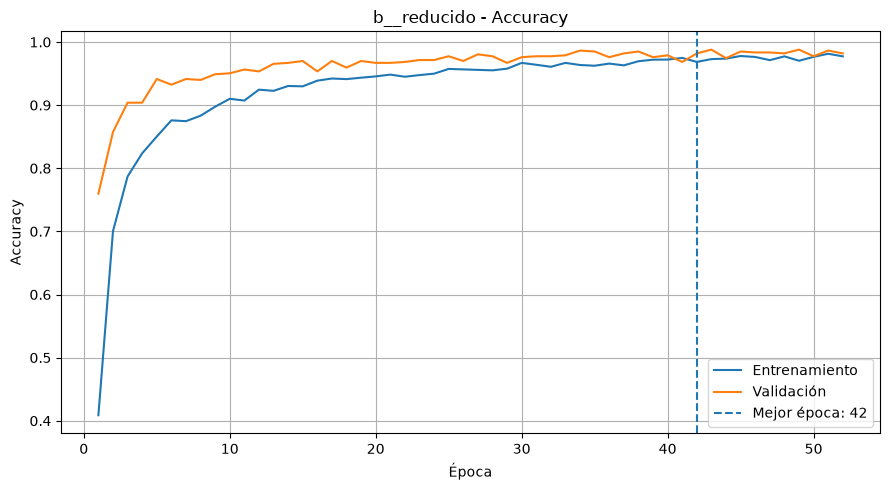

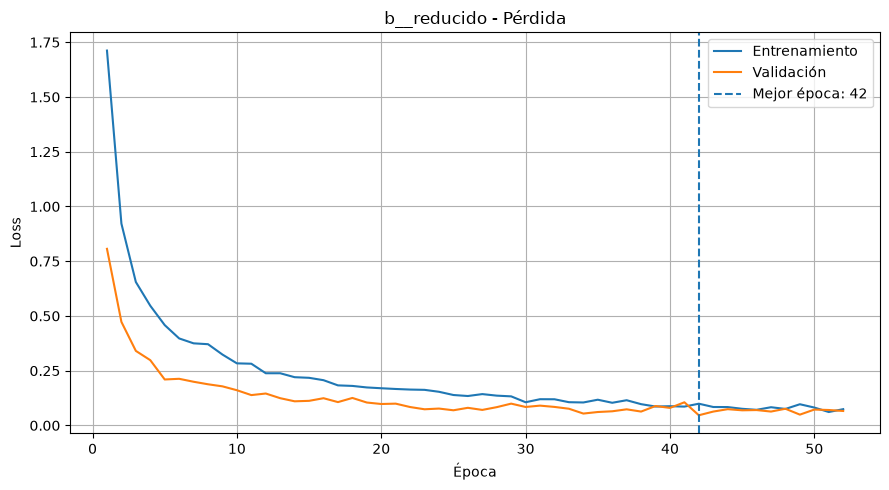

B - Reducido: accuracy=98.20% | loss clasificación=0.046420 | loss total=0.046420

Reutilizando checkpoint: C - L1 1e-5
C:\Users\Bastian\Desktop\Universidad\NOVENO SEMESTRE\IA\TALLER 3\regularizacion\models\v3\checkpoints\modelo_C_L1_1e5_mejor.keras
C - L1 1e-5: accuracy=98.80% | loss clasificación=0.037050 | loss total=0.145714

Entrenando: D - L2 1e-5

Epoch 1/100

Epoch 1: val_loss improved from None to 0.53979, saving model to C:\Users\Bastian\Desktop\Universidad\NOVENO SEMESTRE\IA\TALLER 3\regularizacion\models\v3\checkpoints\modelo_D_L2_1e5_mejor.keras

Epoch 1: finished saving model to C:\Users\Bastian\Desktop\Universidad\NOVENO SEMESTRE\IA\TALLER 3\regularizacion\models\v3\checkpoints\modelo_D_L2_1e5_mejor.keras
167/167 - 5s - 33ms/step - accuracy: 0.4784 - loss: 1.4685 - val_accuracy: 0.8363 - val_loss: 0.5398
Epoch 2/100

Epoch 2: val_loss improved from 0.53979 to 0.30712, saving model to C:\Users\Bastian\Desktop\Universidad\NOVENO SEMESTRE\IA\TALLER 3\regularizacion\models\v

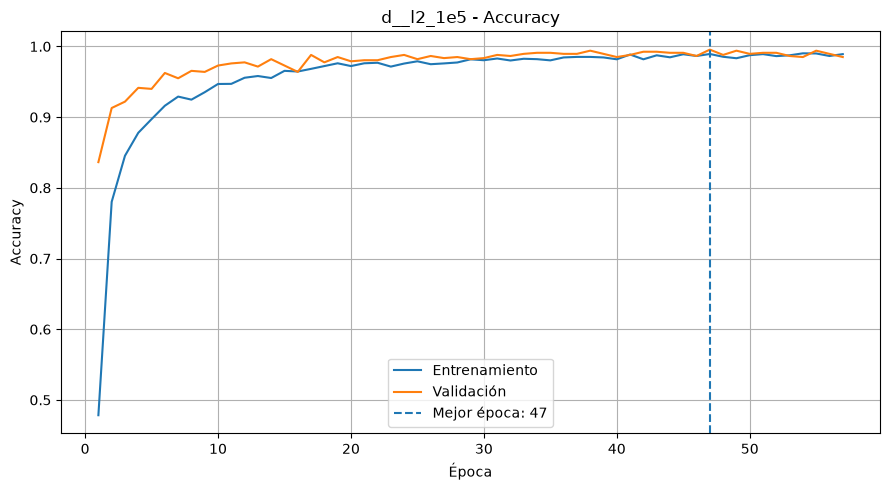

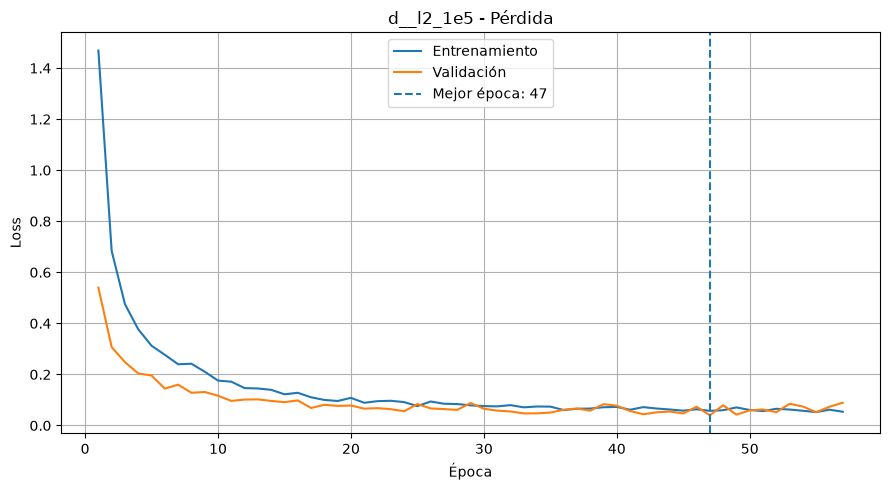

D - L2 1e-5: accuracy=99.55% | loss clasificación=0.019789 | loss total=0.040043

Entrenando: E - Dropout 0.2
Epoch 1/100

Epoch 1: val_loss improved from None to 0.70293, saving model to C:\Users\Bastian\Desktop\Universidad\NOVENO SEMESTRE\IA\TALLER 3\regularizacion\models\v3\checkpoints\modelo_E_Dropout_02_mejor.keras

Epoch 1: finished saving model to C:\Users\Bastian\Desktop\Universidad\NOVENO SEMESTRE\IA\TALLER 3\regularizacion\models\v3\checkpoints\modelo_E_Dropout_02_mejor.keras
167/167 - 5s - 32ms/step - accuracy: 0.4093 - loss: 1.6585 - val_accuracy: 0.7838 - val_loss: 0.7029
Epoch 2/100

Epoch 2: val_loss improved from 0.70293 to 0.36938, saving model to C:\Users\Bastian\Desktop\Universidad\NOVENO SEMESTRE\IA\TALLER 3\regularizacion\models\v3\checkpoints\modelo_E_Dropout_02_mejor.keras

Epoch 2: finished saving model to C:\Users\Bastian\Desktop\Universidad\NOVENO SEMESTRE\IA\TALLER 3\regularizacion\models\v3\checkpoints\modelo_E_Dropout_02_mejor.keras
167/167 - 4s - 25ms/step

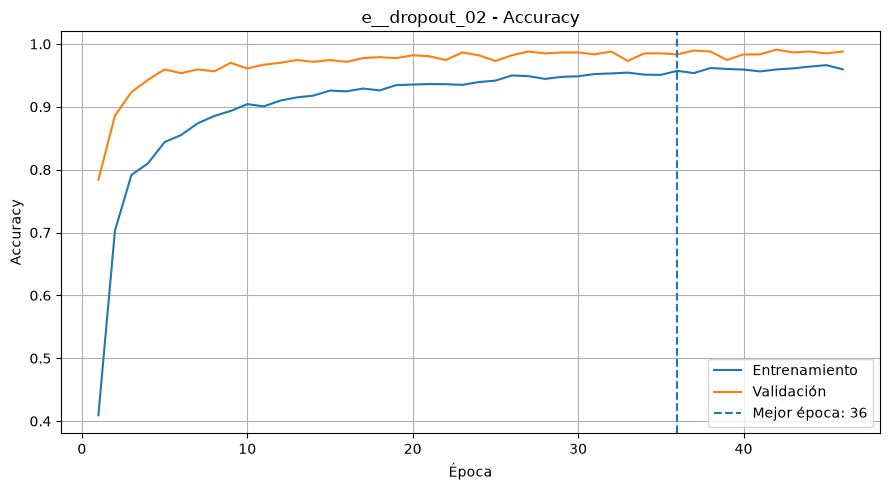

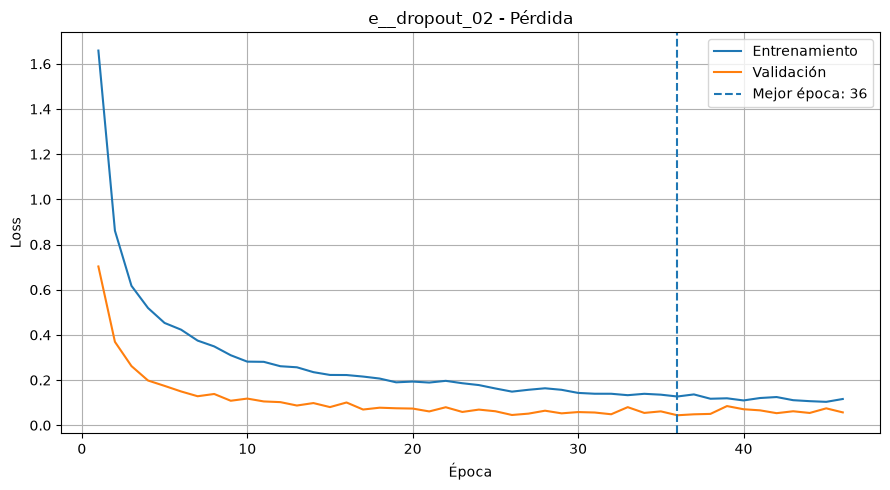

E - Dropout 0.2: accuracy=98.35% | loss clasificación=0.044363 | loss total=0.044363

Comparación terminada.


In [12]:
resultados_ejecucion = []
tablas_por_origen = {}

# Conserva filas anteriores y reemplaza únicamente el modelo actualizado.
tabla_acumulada = resultados_previos.copy()

for nombre in CONFIGURACIONES:
    if not ACTIVAR_MODELO[nombre]:
        print(f"Se omite: {nombre}")
        continue

    resultado, tabla_origen = entrenar_o_cargar(
        nombre=nombre,
        reentrenar=REENTRENAR[nombre],
        seed=SEED,
    )

    resultados_ejecucion.append(resultado)
    tablas_por_origen[nombre] = tabla_origen

    if not tabla_acumulada.empty and "Modelo" in tabla_acumulada.columns:
        tabla_acumulada = tabla_acumulada[
            tabla_acumulada["Modelo"] != nombre
        ].copy()

    tabla_acumulada = pd.concat(
        [
            tabla_acumulada,
            pd.DataFrame([resultado]),
        ],
        ignore_index=True,
        sort=False,
    )

    # Guarda después de cada modelo para no perder avances.
    tabla_acumulada.to_csv(
        RUTA_RESULTADOS,
        index=False,
    )

print("\nComparación terminada.")

## 7. Comparación únicamente en validación

In [13]:
modelos_activos = [
    nombre
    for nombre, activo in ACTIVAR_MODELO.items()
    if activo
]

tabla_resultados = tabla_acumulada[
    tabla_acumulada["Modelo"].isin(modelos_activos)
].copy()

columnas_comparacion = [
    "Modelo",
    "Parametros",
    "Mejor_epoca",
    "Epocas_ejecutadas",
    "Val_accuracy_porcentaje",
    "Val_loss_clasificacion",
    "Penalizacion_regularizacion",
    "Val_loss_total",
    "Val_accuracy_v1",
    "Val_accuracy_v2",
    "Val_accuracy_macro_origen",
    "Brecha_origen_pp",
    "Tiempo_total_minutos",
    "Segundos_por_epoca",
    "Entrenado_en_esta_ejecucion",
]

for columna in columnas_comparacion:
    if columna not in tabla_resultados.columns:
        tabla_resultados[columna] = np.nan

tabla_comparacion = (
    tabla_resultados[columnas_comparacion]
    .sort_values(
        by=[
            "Val_accuracy_porcentaje",
            "Val_accuracy_macro_origen",
            "Val_loss_clasificacion",
            "Brecha_origen_pp",
        ],
        ascending=[False, False, True, True],
    )
    .reset_index(drop=True)
)

tabla_comparacion

,Modelo,Parametros,Mejor_epoca,Epocas_ejecutadas,Val_accuracy_porcentaje,Val_loss_clasificacion,Penalizacion_regularizacion,Val_loss_total,Val_accuracy_v1,Val_accuracy_v2,Val_accuracy_macro_origen,Brecha_origen_pp,Tiempo_total_minutos,Segundos_por_epoca,Entrenado_en_esta_ejecucion
0,D - L2 1e-5,822346,47.0,57.0,99.549550,0.019789,0.020254,0.040043,0.990244,0.997831,0.994037,0.758690,4.213604,4.435373,True
1,A - Base,822346,60.0,70.0,99.249250,0.029059,0.000000,0.029059,0.980488,0.997831,0.989159,1.734300,4.877885,4.181044,False
2,C - L1 1e-5,822346,NaN,NaN,98.798800,0.037050,0.108664,0.145714,0.970732,0.995662,0.983197,2.492990,NaN,NaN,False
3,E - Dropout 0.2,822346,36.0,46.0,98.348349,0.044363,0.000000,0.044363,0.946341,1.000000,0.973171,5.365854,3.261405,4.254007,True
4,B - Reducido,205866,42.0,52.0,98.198199,0.046420,0.000000,0.046420,0.956098,0.993492,0.974795,3.739485,2.023922,2.335295,True


In [14]:
ganador_provisional = tabla_comparacion.iloc[0]

print("GANADOR PROVISIONAL SEGÚN VALIDACIÓN")
print("-" * 55)
print("Modelo:", ganador_provisional["Modelo"])
print(
    "Accuracy general:",
    f'{ganador_provisional["Val_accuracy_porcentaje"]:.2f}%'
)
print(
    "Accuracy v1:",
    f'{ganador_provisional["Val_accuracy_v1"] * 100:.2f}%'
)
print(
    "Accuracy v2:",
    f'{ganador_provisional["Val_accuracy_v2"] * 100:.2f}%'
)
print(
    "Loss de clasificación:",
    f'{ganador_provisional["Val_loss_clasificacion"]:.6f}'
)

print()
print(
    "Este resultado todavía debe comprobarse con semillas adicionales "
    "antes de utilizar el conjunto de prueba."
)

GANADOR PROVISIONAL SEGÚN VALIDACIÓN
-------------------------------------------------------
Modelo: D - L2 1e-5
Accuracy general: 99.55%
Accuracy v1: 99.02%
Accuracy v2: 99.78%
Loss de clasificación: 0.019789

Este resultado todavía debe comprobarse con semillas adicionales antes de utilizar el conjunto de prueba.


## 8. TensorBoard local

Los callbacks ya guardaron las curvas en `regularizacion/outputs/v3/tensorboard`.

En una terminal con el entorno `taller3-train` activado, ejecuta el comando que imprime la siguiente celda. Luego abre `http://localhost:6006`.

In [16]:
print(
    'tensorboard --logdir '
    f'"{TENSORBOARD_DIR}" '
    '--port 6006'
)

tensorboard --logdir "C:\Users\Bastian\Desktop\Universidad\NOVENO SEMESTRE\IA\TALLER 3\regularizacion\outputs\v3\tensorboard" --port 6006


## 9. Siguiente paso

1. Revisar la tabla y TensorBoard.
2. Escoger uno o dos finalistas.
3. Comprobar estabilidad con las semillas `123` y `2026`.
4. Evaluar **una sola vez** el ganador definitivo en el conjunto de prueba.
5. Generar matriz de confusión, reporte de clasificación y exportación TensorFlow.js en un notebook separado.

El conjunto de prueba no se utiliza en este notebook para evitar sesgar la selección del modelo.

El modelo con regularización L2 de factor 1e-5 obtuvo el mejor desempeño en validación, alcanzando una exactitud general de 99,55 % y una pérdida de clasificación de 0,019789. Además, presentó el rendimiento más equilibrado entre los datasets v1 y v2, con una brecha de solo 0,76 puntos porcentuales. En comparación, el modelo base alcanzó 99,25 % y mostró una diferencia mayor entre ambos orígenes. Por esta razón, L2 fue seleccionado como ganador provisional, sujeto a una evaluación de estabilidad con semillas adicionales antes de utilizar el conjunto de prueb

El modelo con regularización L2 de factor 1e-5 obtuvo el mejor desempeño en validación, alcanzando una exactitud general de 99,55 % y una pérdida de clasificación de 0,019789. Además, presentó el rendimiento más equilibrado entre los datasets v1 y v2, con una brecha de solo 0,76 puntos porcentuales. En comparación, el modelo base alcanzó 99,25 % y mostró una diferencia mayor entre ambos orígenes. Por esta razón, L2 fue seleccionado como ganador provisional, sujeto a una evaluación de estabilidad con semillas adicionales antes de utilizar el conjunto de prueb

In [20]:
MODELOS_ESTABILIDAD = [
    "A - Base",
    "D - L2 1e-5",
]

SEMILLAS_NUEVAS = [
    123,
    2026,
]

CHECKPOINTS_ESTABILIDAD_DIR = (
    CHECKPOINTS_DIR / "estabilidad"
)

TENSORBOARD_ESTABILIDAD_DIR = (
    TENSORBOARD_DIR / "estabilidad"
)

HISTORIES_ESTABILIDAD_DIR = (
    HISTORIES_DIR / "estabilidad"
)

for carpeta in [
    CHECKPOINTS_ESTABILIDAD_DIR,
    TENSORBOARD_ESTABILIDAD_DIR,
    HISTORIES_ESTABILIDAD_DIR,
]:
    carpeta.mkdir(
        parents=True,
        exist_ok=True
    )

RUTA_CORRIDAS_ESTABILIDAD = (
    METRICS_DIR
    / "estabilidad_corridas_v3.csv"
)

RUTA_RESUMEN_ESTABILIDAD = (
    METRICS_DIR
    / "estabilidad_resumen_v3.csv"
)

print("Modelos finalistas:", MODELOS_ESTABILIDAD)
print("Semillas nuevas:", SEMILLAS_NUEVAS)

Modelos finalistas: ['A - Base', 'D - L2 1e-5']
Semillas nuevas: [123, 2026]


In [21]:
def entrenar_corrida_estabilidad(
    nombre: str,
    seed: int,
) -> dict:
    nombre_seguro = (
        nombre.lower()
        .replace(" ", "_")
        .replace("-", "")
        .replace(".", "")
    )

    ruta_modelo = (
        CHECKPOINTS_ESTABILIDAD_DIR
        / f"{nombre_seguro}_seed_{seed}_mejor.keras"
    )

    marca_tiempo = (
        datetime.datetime.now()
        .strftime("%Y%m%d-%H%M%S")
    )

    ruta_log = (
        TENSORBOARD_ESTABILIDAD_DIR
        / f"{nombre_seguro}_seed_{seed}_{marca_tiempo}"
    )

    print()
    print("=" * 70)
    print(f"Entrenando {nombre} con semilla {seed}")
    print("=" * 70)

    modelo = crear_modelo(
        nombre,
        seed=seed
    )

    callbacks = [
        EarlyStopping(
            monitor="val_loss",
            patience=PATIENCE,
            restore_best_weights=True,
            verbose=1,
        ),

        ModelCheckpoint(
            filepath=str(ruta_modelo),
            monitor="val_loss",
            save_best_only=True,
            mode="min",
            verbose=1,
        ),

        TensorBoard(
            log_dir=str(ruta_log),
            histogram_freq=0,
        ),
    ]

    inicio = time.perf_counter()

    historial = modelo.fit(
        crear_generador_entrenamiento(seed),
        epochs=EPOCHS,
        validation_data=(X_val, y_val),
        callbacks=callbacks,
        verbose=2,
    )

    tiempo_total = (
        time.perf_counter() - inicio
    )

    mejor_epoca = int(
        np.argmin(
            historial.history["val_loss"]
        ) + 1
    )

    epocas_ejecutadas = len(
        historial.history["loss"]
    )

    # Carga el mejor checkpoint, no el estado
    # correspondiente a la última época.
    modelo_mejor = (
        tf.keras.models.load_model(
            ruta_modelo
        )
    )

    val_loss_total, val_accuracy = (
        modelo_mejor.evaluate(
            X_val,
            y_val,
            verbose=0,
        )
    )

    probabilidades = modelo_mejor(
        X_val,
        training=False,
    ).numpy()

    val_loss_clasificacion = float(
        tf.reduce_mean(
            tf.keras.losses
            .categorical_crossentropy(
                y_val,
                probabilidades,
            )
        ).numpy()
    )

    penalizacion = max(
        0.0,
        float(
            val_loss_total
            - val_loss_clasificacion
        ),
    )

    tabla_origen = evaluar_por_origen(
        probabilidades,
        y_val_enteras,
        origen_val,
    )

    resultados_origen = (
        tabla_origen
        .set_index("Origen")
    )

    accuracy_v1 = float(
        resultados_origen.loc[
            "v1",
            "Accuracy"
        ]
    )

    accuracy_v2 = float(
        resultados_origen.loc[
            "v2",
            "Accuracy"
        ]
    )

    accuracy_macro = float(
        np.mean([
            accuracy_v1,
            accuracy_v2,
        ])
    )

    brecha_pp = (
        abs(accuracy_v1 - accuracy_v2)
        * 100
    )

    # Guarda el historial de esta corrida.
    pd.DataFrame(
        historial.history
    ).to_csv(
        HISTORIES_ESTABILIDAD_DIR
        / f"{nombre_seguro}_seed_{seed}.csv",
        index=False,
    )

    tabla_origen.to_csv(
        METRICS_DIR
        / (
            f"estabilidad_{nombre_seguro}"
            f"_seed_{seed}_por_origen.csv"
        ),
        index=False,
    )

    guardar_curvas(
        historial,
        (
            f"estabilidad_"
            f"{nombre_seguro}_seed_{seed}"
        ),
        mejor_epoca,
    )

    resultado = {
        "Modelo": nombre,
        "Semilla": int(seed),
        "Parametros": int(
            modelo_mejor.count_params()
        ),
        "Mejor_epoca": mejor_epoca,
        "Epocas_ejecutadas": (
            epocas_ejecutadas
        ),
        "Val_accuracy": float(
            val_accuracy
        ),
        "Val_accuracy_porcentaje": float(
            val_accuracy * 100
        ),
        "Val_loss_clasificacion": (
            val_loss_clasificacion
        ),
        "Penalizacion_regularizacion": (
            penalizacion
        ),
        "Val_loss_total": float(
            val_loss_total
        ),
        "Val_accuracy_v1": accuracy_v1,
        "Val_accuracy_v2": accuracy_v2,
        "Val_accuracy_macro_origen": (
            accuracy_macro
        ),
        "Brecha_origen_pp": float(
            brecha_pp
        ),
        "Tiempo_total_minutos": float(
            tiempo_total / 60
        ),
        "Segundos_por_epoca": float(
            tiempo_total
            / epocas_ejecutadas
        ),
        "Ruta_modelo": str(
            ruta_modelo
        ),
    }

    print()
    print(
        f"{nombre} | semilla {seed}"
    )
    print(
        f"Accuracy: "
        f"{val_accuracy * 100:.2f}%"
    )
    print(
        f"Loss clasificación: "
        f"{val_loss_clasificacion:.6f}"
    )
    print(
        f"Accuracy v1: "
        f"{accuracy_v1 * 100:.2f}%"
    )
    print(
        f"Accuracy v2: "
        f"{accuracy_v2 * 100:.2f}%"
    )

    return resultado

In [22]:
corridas_estabilidad = []

for nombre in MODELOS_ESTABILIDAD:
    filas = tabla_resultados[
        tabla_resultados["Modelo"]
        == nombre
    ]

    if filas.empty:
        raise ValueError(
            f"No se encontró el resultado "
            f"de semilla 42 para {nombre}."
        )

    fila = filas.iloc[0]

    corridas_estabilidad.append({
        "Modelo": nombre,
        "Semilla": 42,
        "Parametros": int(
            fila["Parametros"]
        ),
        "Mejor_epoca": (
            fila["Mejor_epoca"]
        ),
        "Epocas_ejecutadas": (
            fila["Epocas_ejecutadas"]
        ),
        "Val_accuracy": float(
            fila["Val_accuracy"]
        ),
        "Val_accuracy_porcentaje": float(
            fila["Val_accuracy_porcentaje"]
        ),
        "Val_loss_clasificacion": float(
            fila["Val_loss_clasificacion"]
        ),
        "Penalizacion_regularizacion": float(
            fila["Penalizacion_regularizacion"]
        ),
        "Val_loss_total": float(
            fila["Val_loss_total"]
        ),
        "Val_accuracy_v1": float(
            fila["Val_accuracy_v1"]
        ),
        "Val_accuracy_v2": float(
            fila["Val_accuracy_v2"]
        ),
        "Val_accuracy_macro_origen": float(
            fila["Val_accuracy_macro_origen"]
        ),
        "Brecha_origen_pp": float(
            fila["Brecha_origen_pp"]
        ),
        "Tiempo_total_minutos": (
            fila["Tiempo_total_minutos"]
        ),
        "Segundos_por_epoca": (
            fila["Segundos_por_epoca"]
        ),
        "Ruta_modelo": (
            fila["Ruta_modelo"]
        ),
    })

tabla_corridas_estabilidad = pd.DataFrame(
    corridas_estabilidad
)

tabla_corridas_estabilidad

,Modelo,Semilla,Parametros,Mejor_epoca,Epocas_ejecutadas,Val_accuracy,Val_accuracy_porcentaje,Val_loss_clasificacion,Penalizacion_regularizacion,Val_loss_total,Val_accuracy_v1,Val_accuracy_v2,Val_accuracy_macro_origen,Brecha_origen_pp,Tiempo_total_minutos,Segundos_por_epoca,Ruta_modelo
0,A - Base,42,822346,60.0,70.0,0.992492,99.24925,0.029059,0.000000,0.029059,0.980488,0.997831,0.989159,1.73430,4.877885,4.181044,C:\Users\Bastian\Desktop\Universidad\NOVENO SE...
1,D - L2 1e-5,42,822346,47.0,57.0,0.995495,99.54955,0.019789,0.020254,0.040043,0.990244,0.997831,0.994037,0.75869,4.213604,4.435373,C:\Users\Bastian\Desktop\Universidad\NOVENO SE...



Entrenando A - Base con semilla 123
Epoch 1/100

Epoch 1: val_loss improved from None to 0.58983, saving model to C:\Users\Bastian\Desktop\Universidad\NOVENO SEMESTRE\IA\TALLER 3\regularizacion\models\v3\checkpoints\estabilidad\a__base_seed_123_mejor.keras

Epoch 1: finished saving model to C:\Users\Bastian\Desktop\Universidad\NOVENO SEMESTRE\IA\TALLER 3\regularizacion\models\v3\checkpoints\estabilidad\a__base_seed_123_mejor.keras
167/167 - 5s - 32ms/step - accuracy: 0.4717 - loss: 1.5175 - val_accuracy: 0.8033 - val_loss: 0.5898
Epoch 2/100

Epoch 2: val_loss improved from 0.58983 to 0.29495, saving model to C:\Users\Bastian\Desktop\Universidad\NOVENO SEMESTRE\IA\TALLER 3\regularizacion\models\v3\checkpoints\estabilidad\a__base_seed_123_mejor.keras

Epoch 2: finished saving model to C:\Users\Bastian\Desktop\Universidad\NOVENO SEMESTRE\IA\TALLER 3\regularizacion\models\v3\checkpoints\estabilidad\a__base_seed_123_mejor.keras
167/167 - 4s - 25ms/step - accuracy: 0.7693 - loss: 0.7045 - 

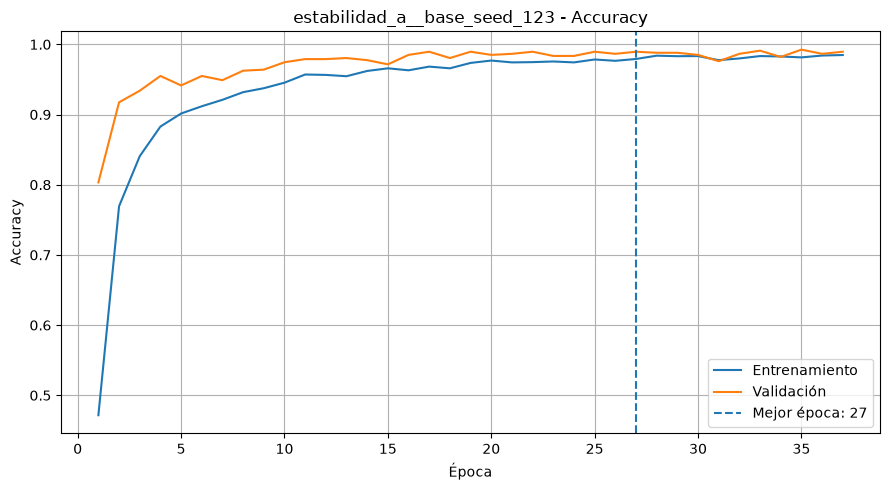

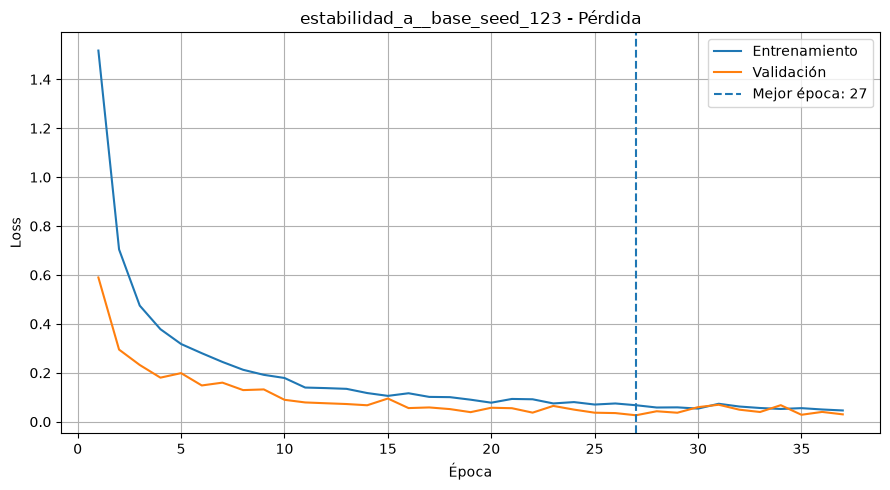


A - Base | semilla 123
Accuracy: 98.95%
Loss clasificación: 0.026436
Accuracy v1: 97.07%
Accuracy v2: 99.78%

Entrenando D - L2 1e-5 con semilla 123
Epoch 1/100

Epoch 1: val_loss improved from None to 0.58860, saving model to C:\Users\Bastian\Desktop\Universidad\NOVENO SEMESTRE\IA\TALLER 3\regularizacion\models\v3\checkpoints\estabilidad\d__l2_1e5_seed_123_mejor.keras

Epoch 1: finished saving model to C:\Users\Bastian\Desktop\Universidad\NOVENO SEMESTRE\IA\TALLER 3\regularizacion\models\v3\checkpoints\estabilidad\d__l2_1e5_seed_123_mejor.keras
167/167 - 5s - 32ms/step - accuracy: 0.4735 - loss: 1.5211 - val_accuracy: 0.7973 - val_loss: 0.5886
Epoch 2/100

Epoch 2: val_loss improved from 0.58860 to 0.31587, saving model to C:\Users\Bastian\Desktop\Universidad\NOVENO SEMESTRE\IA\TALLER 3\regularizacion\models\v3\checkpoints\estabilidad\d__l2_1e5_seed_123_mejor.keras

Epoch 2: finished saving model to C:\Users\Bastian\Desktop\Universidad\NOVENO SEMESTRE\IA\TALLER 3\regularizacion\model

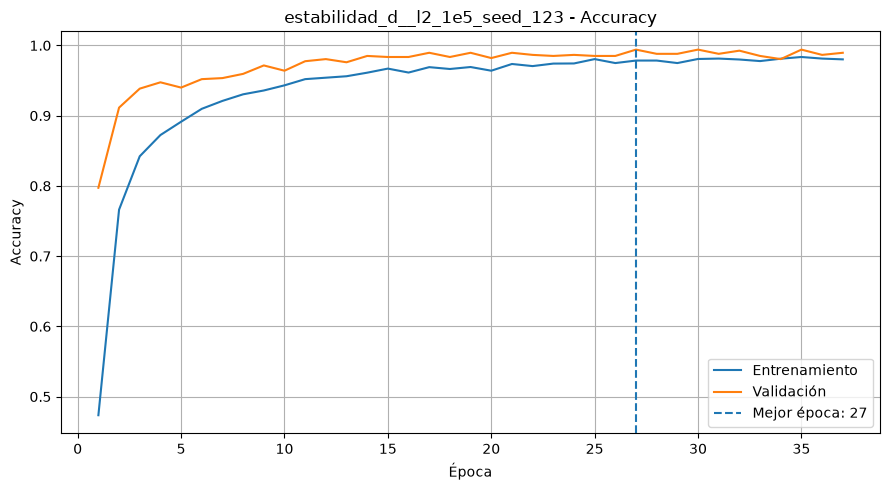

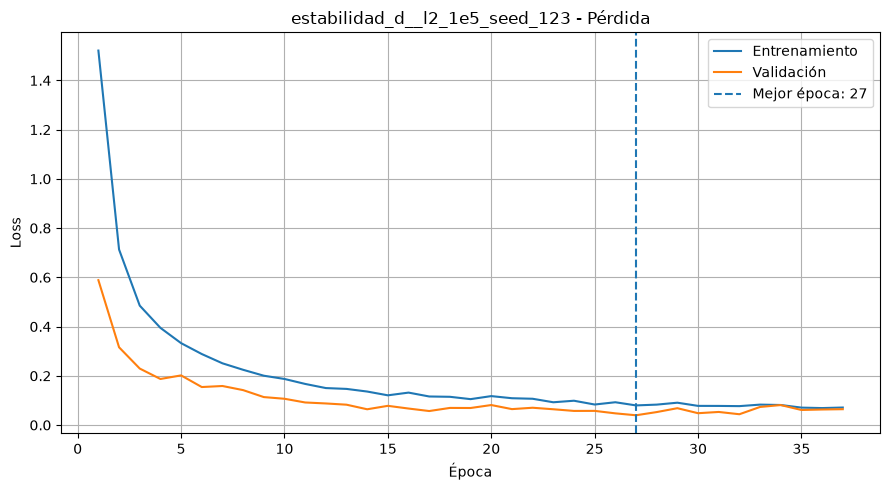


D - L2 1e-5 | semilla 123
Accuracy: 99.40%
Loss clasificación: 0.025051
Accuracy v1: 98.54%
Accuracy v2: 99.78%

Entrenando A - Base con semilla 2026
Epoch 1/100

Epoch 1: val_loss improved from None to 0.59408, saving model to C:\Users\Bastian\Desktop\Universidad\NOVENO SEMESTRE\IA\TALLER 3\regularizacion\models\v3\checkpoints\estabilidad\a__base_seed_2026_mejor.keras

Epoch 1: finished saving model to C:\Users\Bastian\Desktop\Universidad\NOVENO SEMESTRE\IA\TALLER 3\regularizacion\models\v3\checkpoints\estabilidad\a__base_seed_2026_mejor.keras
167/167 - 5s - 31ms/step - accuracy: 0.4366 - loss: 1.6113 - val_accuracy: 0.8438 - val_loss: 0.5941
Epoch 2/100

Epoch 2: val_loss improved from 0.59408 to 0.35878, saving model to C:\Users\Bastian\Desktop\Universidad\NOVENO SEMESTRE\IA\TALLER 3\regularizacion\models\v3\checkpoints\estabilidad\a__base_seed_2026_mejor.keras

Epoch 2: finished saving model to C:\Users\Bastian\Desktop\Universidad\NOVENO SEMESTRE\IA\TALLER 3\regularizacion\models\

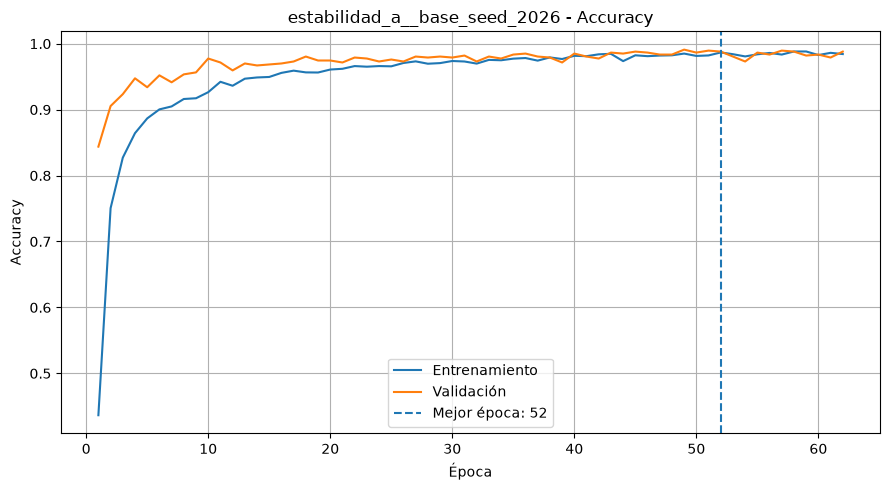

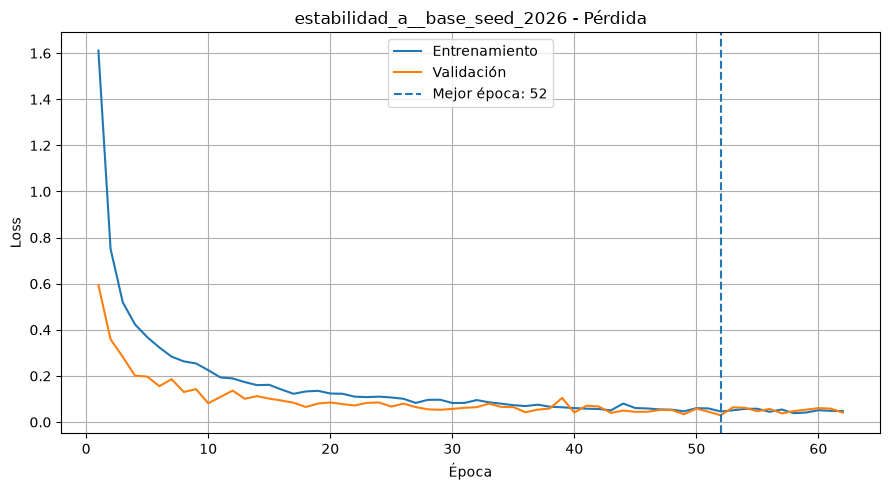


A - Base | semilla 2026
Accuracy: 98.80%
Loss clasificación: 0.029421
Accuracy v1: 96.59%
Accuracy v2: 99.78%

Entrenando D - L2 1e-5 con semilla 2026
Epoch 1/100

Epoch 1: val_loss improved from None to 0.58104, saving model to C:\Users\Bastian\Desktop\Universidad\NOVENO SEMESTRE\IA\TALLER 3\regularizacion\models\v3\checkpoints\estabilidad\d__l2_1e5_seed_2026_mejor.keras

Epoch 1: finished saving model to C:\Users\Bastian\Desktop\Universidad\NOVENO SEMESTRE\IA\TALLER 3\regularizacion\models\v3\checkpoints\estabilidad\d__l2_1e5_seed_2026_mejor.keras
167/167 - 5s - 32ms/step - accuracy: 0.4409 - loss: 1.6095 - val_accuracy: 0.8468 - val_loss: 0.5810
Epoch 2/100

Epoch 2: val_loss improved from 0.58104 to 0.37638, saving model to C:\Users\Bastian\Desktop\Universidad\NOVENO SEMESTRE\IA\TALLER 3\regularizacion\models\v3\checkpoints\estabilidad\d__l2_1e5_seed_2026_mejor.keras

Epoch 2: finished saving model to C:\Users\Bastian\Desktop\Universidad\NOVENO SEMESTRE\IA\TALLER 3\regularizacion\

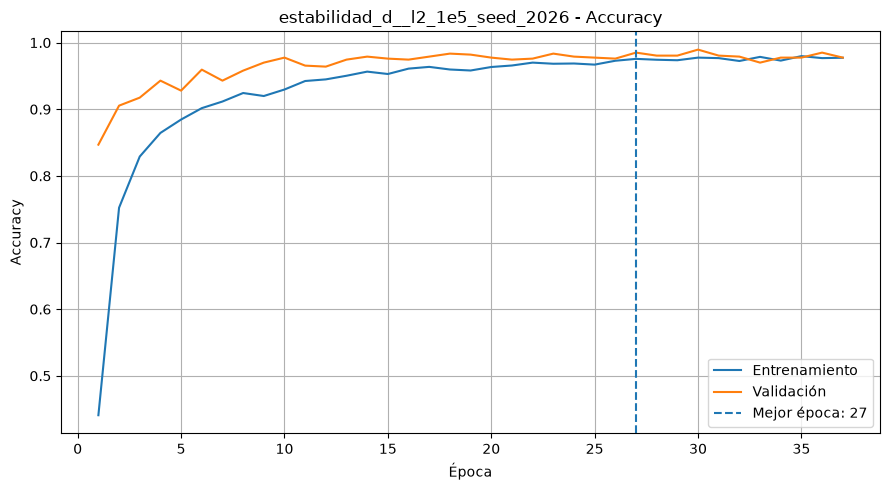

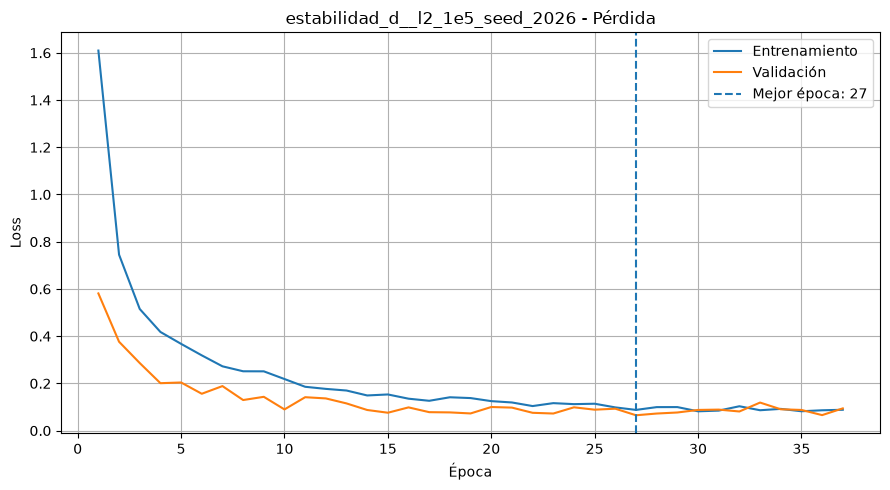


D - L2 1e-5 | semilla 2026
Accuracy: 98.50%
Loss clasificación: 0.054510
Accuracy v1: 96.10%
Accuracy v2: 99.57%

Entrenamientos de estabilidad terminados.


In [23]:
for seed in SEMILLAS_NUEVAS:
    for nombre in MODELOS_ESTABILIDAD:
        resultado = (
            entrenar_corrida_estabilidad(
                nombre=nombre,
                seed=seed,
            )
        )

        corridas_estabilidad.append(
            resultado
        )

        # Respaldo después de cada corrida.
        pd.DataFrame(
            corridas_estabilidad
        ).to_csv(
            RUTA_CORRIDAS_ESTABILIDAD,
            index=False,
        )

print()
print(
    "Entrenamientos de estabilidad "
    "terminados."
)

In [24]:
tabla_corridas_estabilidad = (
    pd.DataFrame(
        corridas_estabilidad
    )
    .sort_values(
        by=[
            "Modelo",
            "Semilla",
        ]
    )
    .reset_index(drop=True)
)

tabla_corridas_estabilidad.to_csv(
    RUTA_CORRIDAS_ESTABILIDAD,
    index=False,
)

columnas_corridas = [
    "Modelo",
    "Semilla",
    "Mejor_epoca",
    "Val_accuracy_porcentaje",
    "Val_loss_clasificacion",
    "Val_accuracy_v1",
    "Val_accuracy_v2",
    "Brecha_origen_pp",
    "Tiempo_total_minutos",
]

tabla_corridas_estabilidad[
    columnas_corridas
]

,Modelo,Semilla,Mejor_epoca,Val_accuracy_porcentaje,Val_loss_clasificacion,Val_accuracy_v1,Val_accuracy_v2,Brecha_origen_pp,Tiempo_total_minutos
0,A - Base,42,60.0,99.249250,0.029059,0.980488,0.997831,1.734300,4.877885
1,A - Base,123,27.0,98.948950,0.026436,0.970732,0.997831,2.709910,2.661633
2,A - Base,2026,52.0,98.798800,0.029421,0.965854,0.997831,3.197714,4.241957
3,D - L2 1e-5,42,47.0,99.549550,0.019789,0.990244,0.997831,0.758690,4.213604
4,D - L2 1e-5,123,27.0,99.399400,0.025051,0.985366,0.997831,1.246495,2.660626
5,D - L2 1e-5,2026,27.0,98.498499,0.054510,0.960976,0.995662,3.468600,2.662381


In [25]:
resumen_estabilidad = (
    tabla_corridas_estabilidad
    .groupby("Modelo")
    .agg(
        Corridas=(
            "Semilla",
            "count"
        ),

        Accuracy_media=(
            "Val_accuracy",
            "mean"
        ),

        Accuracy_std=(
            "Val_accuracy",
            "std"
        ),

        Loss_clasificacion_media=(
            "Val_loss_clasificacion",
            "mean"
        ),

        Loss_clasificacion_std=(
            "Val_loss_clasificacion",
            "std"
        ),

        Accuracy_v1_media=(
            "Val_accuracy_v1",
            "mean"
        ),

        Accuracy_v2_media=(
            "Val_accuracy_v2",
            "mean"
        ),

        Accuracy_macro_origen_media=(
            "Val_accuracy_macro_origen",
            "mean"
        ),

        Brecha_origen_media_pp=(
            "Brecha_origen_pp",
            "mean"
        ),

        Mejor_epoca_media=(
            "Mejor_epoca",
            "mean"
        ),
    )
    .reset_index()
)

resumen_estabilidad[
    "Accuracy_media_porcentaje"
] = (
    resumen_estabilidad[
        "Accuracy_media"
    ] * 100
)

resumen_estabilidad[
    "Accuracy_std_porcentaje"
] = (
    resumen_estabilidad[
        "Accuracy_std"
    ] * 100
)

resumen_estabilidad = (
    resumen_estabilidad
    .sort_values(
        by=[
            "Accuracy_media",
            "Accuracy_std",
            "Loss_clasificacion_media",
        ],
        ascending=[
            False,
            True,
            True,
        ],
    )
    .reset_index(drop=True)
)

resumen_estabilidad.to_csv(
    RUTA_RESUMEN_ESTABILIDAD,
    index=False,
)

resumen_estabilidad

,Modelo,Corridas,Accuracy_media,Accuracy_std,Loss_clasificacion_media,Loss_clasificacion_std,Accuracy_v1_media,Accuracy_v2_media,Accuracy_macro_origen_media,Brecha_origen_media_pp,Mejor_epoca_media,Accuracy_media_porcentaje,Accuracy_std_porcentaje
0,D - L2 1e-5,3,0.991491,0.005685,0.033117,0.018713,0.978862,0.997108,0.987985,1.824595,33.666667,99.14915,0.568459
1,A - Base,3,0.989990,0.002294,0.028305,0.001629,0.972358,0.997831,0.985094,2.547308,46.333333,98.99900,0.229358


In [26]:
ganador_estable = (
    resumen_estabilidad.iloc[0]
)

print(
    "GANADOR SEGÚN ESTABILIDAD"
)

print("-" * 55)

print(
    "Modelo:",
    ganador_estable["Modelo"]
)

print(
    f"Accuracy media: "
    f"{ganador_estable['Accuracy_media_porcentaje']:.2f}%"
)

print(
    f"Desviación estándar: "
    f"{ganador_estable['Accuracy_std_porcentaje']:.3f} puntos"
)

print(
    f"Loss de clasificación media: "
    f"{ganador_estable['Loss_clasificacion_media']:.6f}"
)

print(
    f"Accuracy media v1: "
    f"{ganador_estable['Accuracy_v1_media'] * 100:.2f}%"
)

print(
    f"Accuracy media v2: "
    f"{ganador_estable['Accuracy_v2_media'] * 100:.2f}%"
)

GANADOR SEGÚN ESTABILIDAD
-------------------------------------------------------
Modelo: D - L2 1e-5
Accuracy media: 99.15%
Desviación estándar: 0.568 puntos
Loss de clasificación media: 0.033117
Accuracy media v1: 97.89%
Accuracy media v2: 99.71%


In [29]:
# Cargar el conjunto de prueba reservado.
X_test = np.asarray(
    X[indices_test],
    dtype=np.float32
)

y_test_enteras = y_enteras[
    indices_test
].astype(np.int32)

y_test = to_categorical(
    y_test_enteras,
    num_classes=10
).astype(np.float32)

origen_test = metadata.iloc[
    indices_test
]["Origen"].to_numpy()

print("Conjunto de prueba cargado")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)
print("y_test_enteras:", y_test_enteras.shape)

print(
    "Origen de prueba:",
    pd.Series(origen_test)
    .value_counts()
    .to_dict()
)

Conjunto de prueba cargado
X_test: (666, 64, 64, 1)
y_test: (666, 10)
y_test_enteras: (666,)
Origen de prueba: {'v2': 460, 'v1': 206}


In [30]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

ruta_modelo_ganador = (
    CHECKPOINTS_DIR
    / "modelo_D_L2_1e5_mejor.keras"
)

if not ruta_modelo_ganador.exists():
    raise FileNotFoundError(
        f"No se encontró el checkpoint ganador:\n"
        f"{ruta_modelo_ganador}"
    )

modelo_final = tf.keras.models.load_model(
    ruta_modelo_ganador
)

print("Modelo final cargado:")
print(ruta_modelo_ganador)
print("Parámetros:", modelo_final.count_params())

Modelo final cargado:
C:\Users\Bastian\Desktop\Universidad\NOVENO SEMESTRE\IA\TALLER 3\regularizacion\models\v3\checkpoints\modelo_D_L2_1e5_mejor.keras
Parámetros: 822346


In [31]:
test_loss_total, test_accuracy = (
    modelo_final.evaluate(
        X_test,
        y_test,
        verbose=0,
    )
)

probabilidades_test = modelo_final(
    X_test,
    training=False,
).numpy()

predicciones_test = np.argmax(
    probabilidades_test,
    axis=1,
)

test_loss_clasificacion = float(
    tf.reduce_mean(
        tf.keras.losses
        .categorical_crossentropy(
            y_test,
            probabilidades_test,
        )
    ).numpy()
)

test_penalizacion_l2 = max(
    0.0,
    float(
        test_loss_total
        - test_loss_clasificacion
    ),
)

print("EVALUACIÓN FINAL EN PRUEBA")
print("-" * 55)

print(
    f"Accuracy de prueba: "
    f"{test_accuracy * 100:.2f}%"
)

print(
    f"Pérdida de clasificación: "
    f"{test_loss_clasificacion:.6f}"
)

print(
    f"Penalización L2: "
    f"{test_penalizacion_l2:.6f}"
)

print(
    f"Pérdida total: "
    f"{test_loss_total:.6f}"
)

print(
    "Aciertos:",
    int(
        np.sum(
            predicciones_test
            == y_test_enteras
        )
    ),
    "de",
    len(y_test_enteras),
)

EVALUACIÓN FINAL EN PRUEBA
-------------------------------------------------------
Accuracy de prueba: 99.10%
Pérdida de clasificación: 0.034009
Penalización L2: 0.020254
Pérdida total: 0.054263
Aciertos: 660 de 666


In [32]:
origen_test = metadata.iloc[
    indices_test
]["Origen"].to_numpy()

In [33]:
tabla_test_origen = evaluar_por_origen(
    probabilidades_test,
    y_test_enteras,
    origen_test,
)

tabla_test_origen.to_csv(
    METRICS_DIR
    / "modelo_final_test_por_origen.csv",
    index=False,
)

tabla_test_origen

,Origen,Cantidad,Accuracy,Accuracy_porcentaje,Loss_clasificacion
0,v1,206,0.975728,97.572816,0.095315
1,v2,460,0.997826,99.782609,0.006556


In [34]:
reporte_test = classification_report(
    y_test_enteras,
    predicciones_test,
    labels=np.arange(10),
    target_names=[
        str(digito)
        for digito in range(10)
    ],
    output_dict=True,
    zero_division=0,
)

tabla_reporte_test = (
    pd.DataFrame(reporte_test)
    .transpose()
)

tabla_reporte_test.to_csv(
    METRICS_DIR
    / "reporte_clasificacion_test.csv",
    index=True,
)

tabla_reporte_test

,precision,recall,f1-score,support
0,1.000000,1.000000,1.000000,62.000000
1,1.000000,1.000000,1.000000,71.000000
2,1.000000,1.000000,1.000000,71.000000
3,1.000000,1.000000,1.000000,62.000000
4,0.985294,0.971014,0.978102,69.000000
5,1.000000,1.000000,1.000000,70.000000
6,0.984848,0.984848,0.984848,66.000000
7,0.939394,0.984127,0.961240,63.000000
8,1.000000,0.983871,0.991870,62.000000
9,1.000000,0.985714,0.992806,70.000000


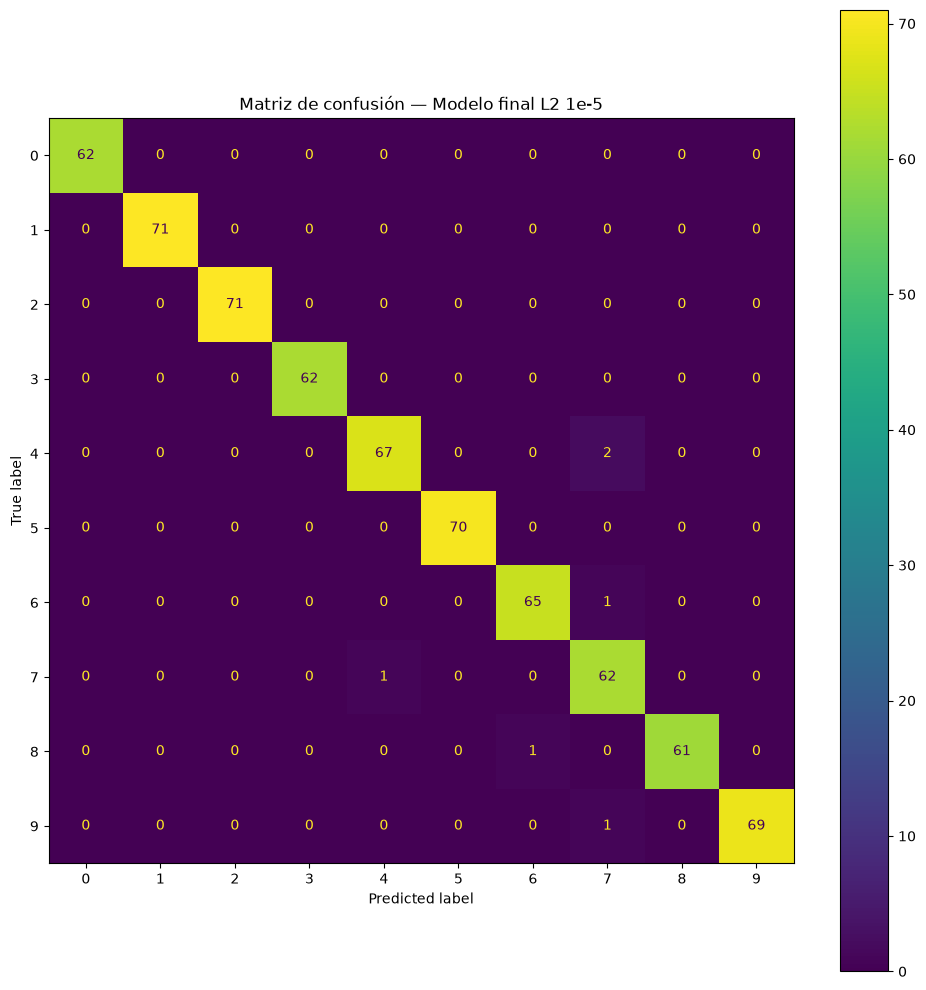

In [35]:
matriz_test = confusion_matrix(
    y_test_enteras,
    predicciones_test,
    labels=np.arange(10),
)

fig, ax = plt.subplots(
    figsize=(10, 10)
)

visualizacion = ConfusionMatrixDisplay(
    confusion_matrix=matriz_test,
    display_labels=np.arange(10),
)

visualizacion.plot(
    ax=ax,
    values_format="d",
)

ax.set_title(
    "Matriz de confusión — Modelo final L2 1e-5"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "matriz_confusion_modelo_final_test.png",
    dpi=250,
    bbox_inches="tight",
)

plt.show()

In [36]:
FINAL_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

ruta_modelo_final = (
    FINAL_DIR
    / "modelo_final_L2_1e5_v3.keras"
)

modelo_final.save(
    ruta_modelo_final
)

resumen_test = pd.DataFrame([
    {
        "Modelo": "D - L2 1e-5",
        "Semilla": 42,
        "Cantidad_test": len(
            y_test_enteras
        ),
        "Test_accuracy": float(
            test_accuracy
        ),
        "Test_accuracy_porcentaje": float(
            test_accuracy * 100
        ),
        "Test_loss_clasificacion": float(
            test_loss_clasificacion
        ),
        "Penalizacion_L2": float(
            test_penalizacion_l2
        ),
        "Test_loss_total": float(
            test_loss_total
        ),
        "Ruta_modelo_final": str(
            ruta_modelo_final
        ),
    }
])

resumen_test.to_csv(
    METRICS_DIR
    / "resultado_final_test.csv",
    index=False,
)

print("Modelo final guardado en:")
print(ruta_modelo_final)

Modelo final guardado en:
C:\Users\Bastian\Desktop\Universidad\NOVENO SEMESTRE\IA\TALLER 3\regularizacion\models\v3\final\modelo_final_L2_1e5_v3.keras
